GPU - Training Time: 0.23s
GPU - Accuracy: 0.9675
GPU - F1 Score: 0.9723


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [14:04:54] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  "nthread": self.nthread,


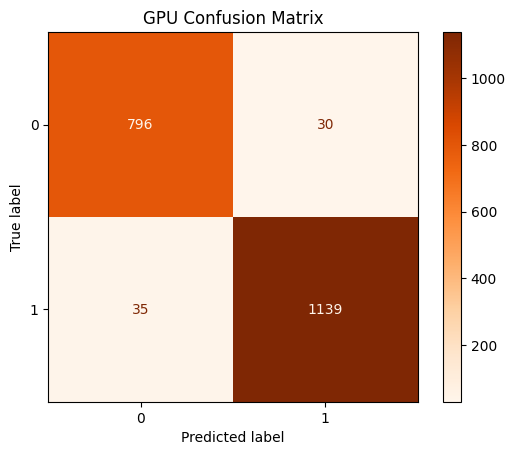

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
import time


df = pd.read_csv("StudentPerformance.csv")

df['pass'] = (df['Performance Index'] >= 50).astype(int)

le = LabelEncoder()
df['Extracurricular Activities'] = le.fit_transform(df['Extracurricular Activities'])


X = df.drop(['Performance Index', 'pass'], axis=1)
y = df['pass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()

model_gpu = xgb.XGBClassifier(
    tree_method="hist",
    device="cuda",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)


start = time.time()
model_gpu.fit(X_train, y_train)
gpu_time = time.time() - start


y_pred = model_gpu.predict(X_test)

gpu_acc = accuracy_score(y_test, y_pred)
gpu_f1 = f1_score(y_test, y_pred)

print(f"GPU Training Time: {gpu_time:.2f}s")
print(f"GPU Accuracy: {gpu_acc:.4f}")
print(f"GPU F1 Score: {gpu_f1:.4f}")


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Oranges"
)

plt.title("GPU Confusion Matrix")


plt.xticks([])
plt.yticks([])

plt.show()
